# **Diccionario de variables**

01 - PatientId

Identificación única del paciente

02 - AppointmentID

Identificación única de la cita médica

03 - Gender

Male o Female

04 - DataMarcacaoConsulta

Día de la cita médica donde se supone que deben ver al médico

05 - DataAgendamento

El día cuando se programó la cita médica

06 - Age

Edad del paciente

07 - Neighbourhood

Lugar donde la cita se va a dar lugar

08 - Scholarship

True of False. Si el poaciente tiene algún tipo de beca

09 - Hipertension

True or False. Si el paciente tiene historial de hipertensión

10 - Diabetes

True or False. Si el paciente tiene diabetes

11 - Alcoholism

True or False. Si el paciente padece de alcoholismo o ha tenido un historial

12 - Handicap

True or False. Si el paciente tiene alguna discapacidad física

13 - SMS_received

Cuántos mensajes fueron enviados al paciente para recordarle de la cita médica

14 - No-show

True or False. Bandera que muestra si el paciente se presentó o no a la cita médica

## EDA

Importación de librerías necesarias

In [ ]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Cargar los datos en crudo para empezar el EDA
raw_data = pd.read_csv('data/Raw Data.csv')

In [ ]:
print("El tamaño del dataframe es: {}".format(raw_data.shape))

El tamaño del dataframe es: (110527, 14)


In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [ ]:
raw_data.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
#Corregimos PatientID para que sea de tipo string y pueda ser identificable
raw_data['PatientId'] = raw_data['PatientId'].astype(int)
raw_data['PatientId'] = raw_data['PatientId'].astype(str)

#AppointmentID también se conveirte a tipo string
raw_data['AppointmentID'] = raw_data['AppointmentID'].astype(str)

#Cambiamos los valores de género de M -> 1 y F -> 0
raw_data['Gender'] = raw_data['Gender'].map({'M': '1', 'F': '0'})

#ScheduledDay y AppointmentDay serán cambiados de tipo de datos de string a date time
raw_data['ScheduledDay'] = pd.to_datetime(raw_data['ScheduledDay']).dt.date.astype('datetime64[ns]')
raw_data['AppointmentDay'] = pd.to_datetime(raw_data['AppointmentDay']).dt.date.astype('datetime64[ns]')

#Se realiza un cambio de nombre a las variables para un mejor entendimiento de los datos
raw_data = raw_data.rename(columns={'Handcap': 'Handicap', 'No-show': 'NoShow'})

In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   PatientId       110527 non-null  object        
 1   AppointmentID   110527 non-null  object        
 2   Gender          110527 non-null  object        
 3   ScheduledDay    110527 non-null  datetime64[ns]
 4   AppointmentDay  110527 non-null  datetime64[ns]
 5   Age             110527 non-null  int64         
 6   Neighbourhood   110527 non-null  object        
 7   Scholarship     110527 non-null  int64         
 8   Hipertension    110527 non-null  int64         
 9   Diabetes        110527 non-null  int64         
 10  Alcoholism      110527 non-null  int64         
 11  Handicap        110527 non-null  int64         
 12  SMS_received    110527 non-null  int64         
 13  NoShow          110527 non-null  object        
dtypes: datetime64[ns](2), int64(7), obje

In [ ]:
raw_data.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handicap,SMS_received,NoShow
0,29872499824296,5642903,0,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438,5642503,1,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951,5642549,0,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174,5642828,0,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183,5642494,0,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
#Obtenemos el número del día de la semana donde se hizo la cita médica a partir del ScheduledDay
raw_data['ScheduledDay_DayOfWeek'] = raw_data['ScheduledDay'].dt.dayofweek

#Obtenemos el día de la semana programado para la cita médica a partir de AppointmentDay
raw_data['AppointmentDay_DayOfWeek'] = raw_data['AppointmentDay'].dt.dayofweek

#Obtenemos la diferencia de días entre el día que se realizó la cita y el día cuando debía presentarse el paciente
raw_data['DaysToAppointment'] = (raw_data['AppointmentDay'] - raw_data['ScheduledDay']).dt.days

In [ ]:
print(raw_data['Age'].unique())

[ 62  56   8  76  23  39  21  19  30  29  22  28  54  15  50  40  46   4
  13  65  45  51  32  12  61  38  79  18  63  64  85  59  55  71  49  78
  31  58  27   6   2  11   7   0   3   1  69  68  60  67  36  10  35  20
  26  34  33  16  42   5  47  17  41  44  37  24  66  77  81  70  53  75
  73  52  74  43  89  57  14   9  48  83  72  25  80  87  88  84  82  90
  94  86  91  98  92  96  93  95  97 102 115 100  99  -1]


In [ ]:
print("Pacientes con edad de -1 o menos: {}".format(raw_data[raw_data.Age == -1].shape[0]))
print("Pacientes con edad de 0: {}".format(raw_data[raw_data.Age == 0].shape[0]))

Pacientes con edad de -1 o menos: 1
Pacientes con edad de 0: 3539


In [ ]:
#Asumimos que el paciente con edad de -1 es un error humano y lo eliminamos del dataset
#Para los pacientes con edad igual a 0 se mantienen en el dataset porque se los asocia a niños recién nacidos
raw_data = raw_data[raw_data.Age != -1]

In [ ]:
#Se genera un rango de edades para poder visualizar mejor la información
bins = [0, 12, 17, 24, 44, 64, float('inf')]
labels = [
    'Children (0–12)',
    'Adolescence (13–17)',
    'Young Adult (18–24)',
    'Adult (25–44)',
    'Senior (45–64)',
    'Elder (65+)'
]

# Crea la columna con los grupos de edad
raw_data['AgeGroup'] = pd.cut(raw_data['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

## Visualización del dataset

/tmp/ipython-input-1806546739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='NoShow', data=raw_data, palette=custom_palette)


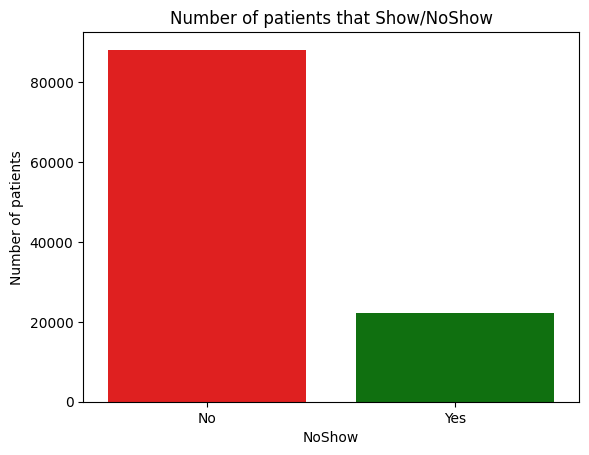

In [ ]:
#Visualizar el número de pacientes que no se presentaron

custom_palette = {'Yes': 'green', 'No': 'red'}

ax = sns.countplot(x='NoShow', data=raw_data, palette=custom_palette)

ax.set_title("Number of patients that Show/NoShow")
ax.set_xlabel("NoShow")
ax.set_ylabel("Number of patients")
plt.show()

/tmp/ipython-input-365288182.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = raw_data.groupby(['AgeGroup', 'Gender'])['PatientId'].count().reset_index()


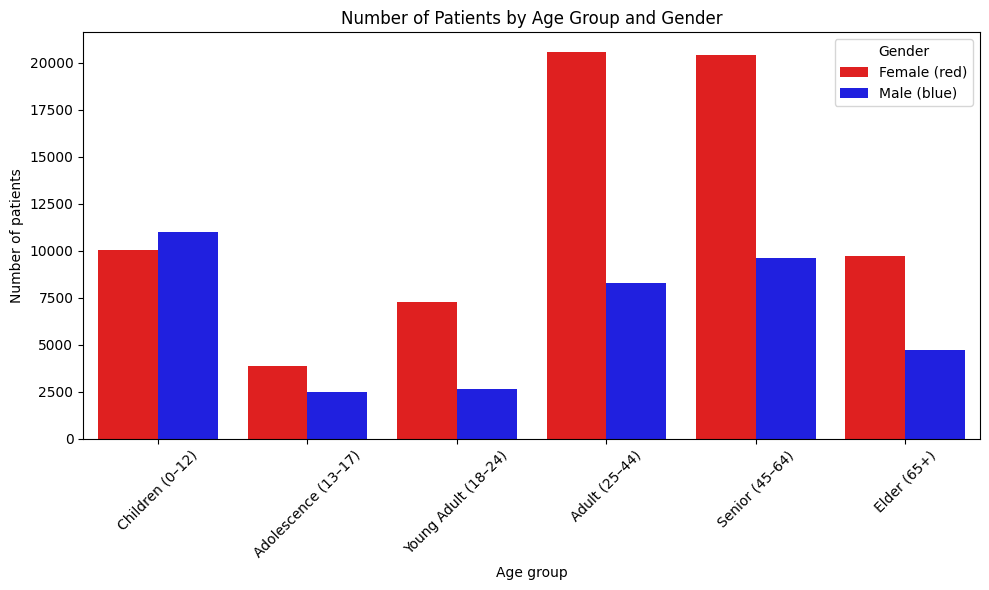

In [ ]:
#Se crea una gráfica para visualizar la información demográfica por género

count_data = raw_data.groupby(['AgeGroup', 'Gender'])['PatientId'].count().reset_index()

# Paleta de colores correcta según los valores de 'Gender'
palette = {'0': 'red', '1': 'blue'}

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=count_data,
    x='AgeGroup',
    y='PatientId',
    hue='Gender',
    palette=palette
)

plt.title('Number of Patients by Age Group and Gender')
plt.xlabel('Age group')
plt.ylabel('Number of patients')
plt.xticks(rotation=45)

handles, labels = ax.get_legend_handles_labels()

label_map = {'0': 'Female', '1': 'Male'}
labels = [f"{label_map[l]} ({palette[l]})" for l in labels]

plt.legend(handles, labels, title='Gender')

plt.tight_layout()
plt.show()

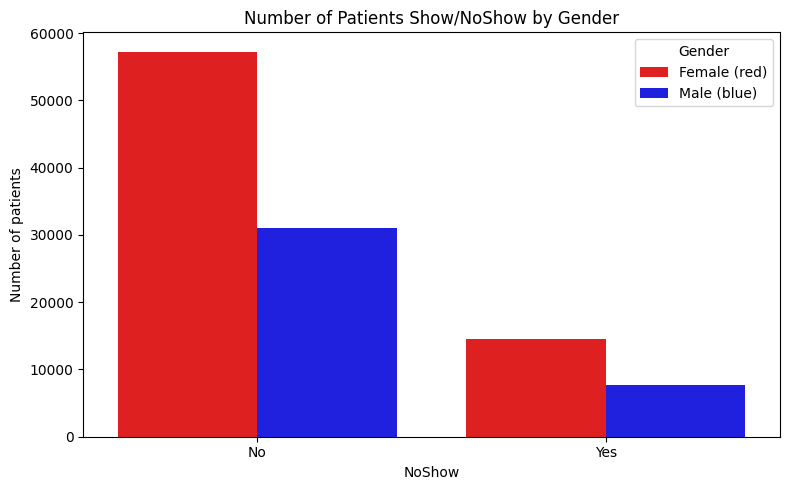

In [ ]:
count_data = raw_data.groupby(['NoShow', 'Gender'])['PatientId'].count().reset_index()

palette = {'0': 'red', '1': 'blue'}
count_data['Gender'] = count_data['Gender'].astype(str)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=count_data,
    x='NoShow',
    y='PatientId',
    hue='Gender',
    palette=palette
)

ax.set_title("Number of Patients Show/NoShow by Gender")
ax.set_xlabel("NoShow")
ax.set_ylabel("Number of patients")

handles, labels = ax.get_legend_handles_labels()

label_map = {'0': 'Female', '1': 'Male'}
labels = [f"{label_map[l]} ({palette[l]})" for l in labels]

plt.legend(handles, labels, title='Gender')

plt.tight_layout()
plt.show()

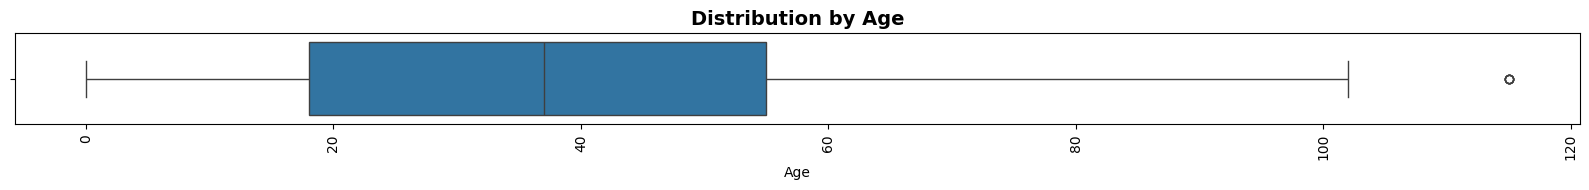

In [ ]:
plt.figure(figsize=(16, 2))
sns.boxplot(x=raw_data['Age'])
plt.title('Distribution by Age', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2678507132.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


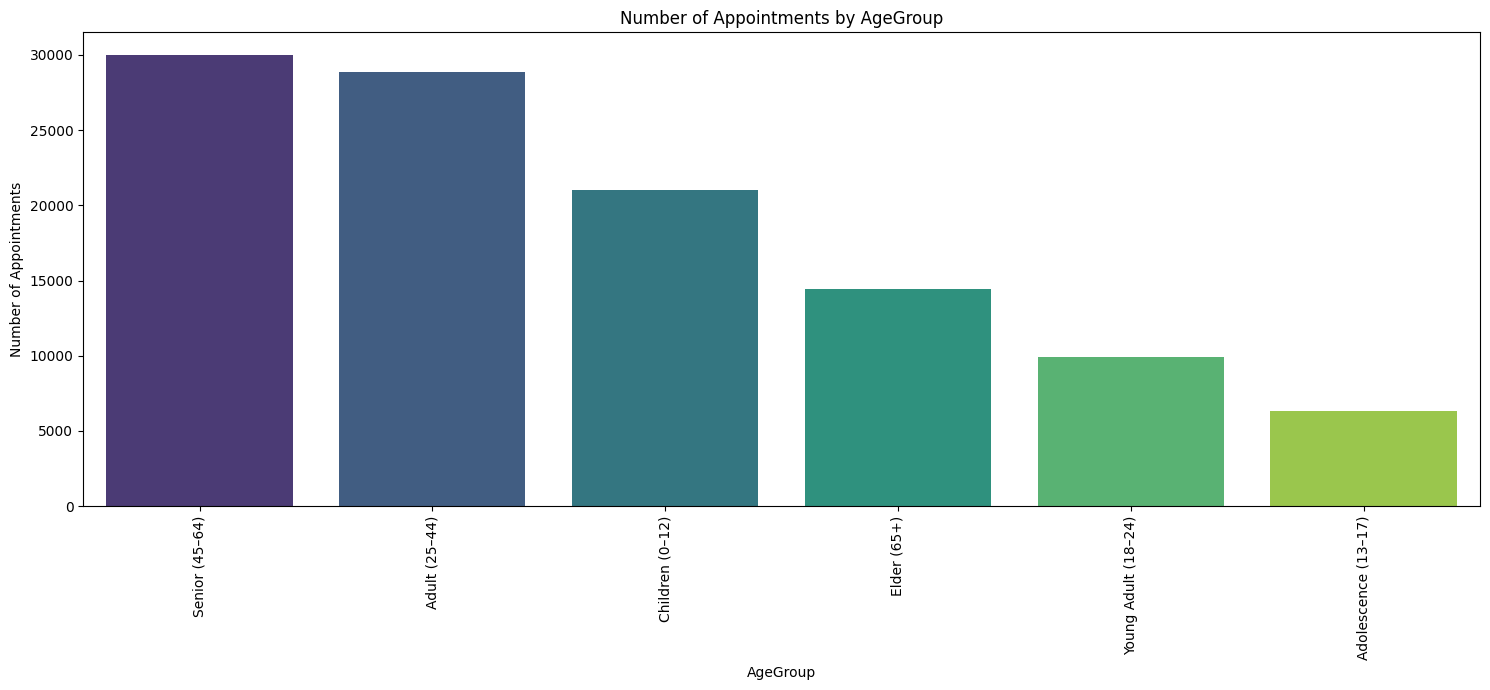

In [ ]:
age_counts = raw_data['AgeGroup'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(15, 7))
plt.xticks(rotation=90)

ax = sns.countplot(
    x='AgeGroup',
    data=raw_data,
    order=age_counts.index,
    palette='viridis'
)

ax.set_title("Number of Appointments by AgeGroup")
ax.set_xlabel("AgeGroup")
ax.set_ylabel("Number of Appointments")

plt.tight_layout()
plt.show()

In [ ]:
cleaned = raw_data.copy()

In [ ]:
cleaned.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'NoShow',
       'ScheduledDay_DayOfWeek', 'AppointmentDay_DayOfWeek',
       'DaysToAppointment', 'AgeGroup'],
      dtype='object')

In [ ]:
cleaned = cleaned[['Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'NoShow',
       'ScheduledDay_DayOfWeek', 'AppointmentDay_DayOfWeek',
       'DaysToAppointment']]

In [ ]:
cleaned.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handicap,SMS_received,NoShow,ScheduledDay_DayOfWeek,AppointmentDay_DayOfWeek,DaysToAppointment
0,0,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,No,4,4,0
1,1,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,No,4,4,0
2,0,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,No,4,4,0
3,0,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,4,4,0
4,0,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,No,4,4,0


In [ ]:
#Usamos label encoder para las variables categoricas
LabelE = LabelEncoder()

#Neighbourhood
cleaned['Neighbourhood'] = LabelE.fit_transform(cleaned['Neighbourhood'])

#NoShow
cleaned['NoShow'] = cleaned['NoShow'].apply(lambda x: 0 if x == 'No' else 1)

In [ ]:
cleaned.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handicap,SMS_received,NoShow,ScheduledDay_DayOfWeek,AppointmentDay_DayOfWeek,DaysToAppointment
0,0,2016-04-29,2016-04-29,62,39,0,1,0,0,0,0,0,4,4,0
1,1,2016-04-29,2016-04-29,56,39,0,0,0,0,0,0,0,4,4,0
2,0,2016-04-29,2016-04-29,62,45,0,0,0,0,0,0,0,4,4,0
3,0,2016-04-29,2016-04-29,8,54,0,0,0,0,0,0,0,4,4,0
4,0,2016-04-29,2016-04-29,56,39,0,1,1,0,0,0,0,4,4,0


In [ ]:
cleaned['ScheduledDay_Year'] = cleaned['ScheduledDay'].dt.year
cleaned['ScheduledDay_Month'] = cleaned['ScheduledDay'].dt.month
cleaned.drop(['ScheduledDay'], axis=1, inplace=True)

cleaned['AppointmentDay_Year'] = cleaned['AppointmentDay'].dt.year
cleaned['AppointmentDay_Month'] = cleaned['AppointmentDay'].dt.month
cleaned.drop(['AppointmentDay'], axis=1, inplace=True)

In [ ]:
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Gender                    110526 non-null  object
 1   Age                       110526 non-null  int64 
 2   Neighbourhood             110526 non-null  int64 
 3   Scholarship               110526 non-null  int64 
 4   Hipertension              110526 non-null  int64 
 5   Diabetes                  110526 non-null  int64 
 6   Alcoholism                110526 non-null  int64 
 7   Handicap                  110526 non-null  int64 
 8   SMS_received              110526 non-null  int64 
 9   NoShow                    110526 non-null  int64 
 10  ScheduledDay_DayOfWeek    110526 non-null  int32 
 11  AppointmentDay_DayOfWeek  110526 non-null  int32 
 12  DaysToAppointment         110526 non-null  int64 
 13  ScheduledDay_Year         110526 non-null  int32 
 14  Scheduled

In [ ]:
cleaned.to_csv('data/Cleaned.csv', index=False)